<a href="https://colab.research.google.com/github/DhritiKothari/Handwriting-Analysis/blob/main/handwriting_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix



In [ ]:
from google.colab import drive
drive.mount('/content/drive')




Mounted at /content/drive


In [ ]:
DATASET_ROOT = "/content/drive/MyDrive/handwriting_dataset"
PREPROCESS_DIR = "/content/drive/MyDrive/preprocessed_images"

os.makedirs(PREPROCESS_DIR, exist_ok=True)


In [7]:
all_images = []

for folder in os.listdir(DATASET_ROOT):
    folder_path = os.path.join(DATASET_ROOT, folder)
    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(folder_path, file))

print("Total images found:", len(all_images))




Total images found: 1340


In [15]:
import cv2
import numpy as np
import os

for img_path in all_images:
    img = cv2.imread(img_path)
    if img is None:
        continue

    # 1. Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Noise reduction
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # 3. Contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)

    # 4. Adaptive thresholding (foreground = white)
    binary = cv2.adaptiveThreshold(
        enhanced,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        15,
        5
    )

    # 5. Light morphology (clean noise then slightly thicken strokes)
    kernel = np.ones((2,2), np.uint8)
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    # 6. Final hard binarization
    _, final = cv2.threshold(cleaned, 127, 255, cv2.THRESH_BINARY)

    # Save with unique name
    folder = os.path.basename(os.path.dirname(img_path))
    filename = f"{folder}_{os.path.basename(img_path)}"
    cv2.imwrite(os.path.join(PREPROCESS_DIR, filename), final)

print("✅ Preprocessing completed.")


✅ Preprocessing completed.


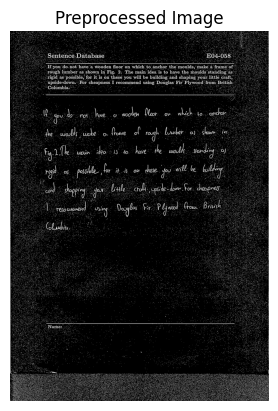

In [16]:
test_img = os.listdir(PREPROCESS_DIR)[0]
img = cv2.imread(os.path.join(PREPROCESS_DIR, test_img), cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()


In [17]:
def extract_slant(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return 0.0

    edges = cv2.Canny(img, 50, 150)

    # We use a slightly lower threshold (100) to ensure we detect short strokes
    lines = cv2.HoughLines(edges, 1, np.pi / 180, 100)
    if lines is None:
        return 0.0

    angles = []
    for line in lines[:50]: # Checking more lines gives a better statistical 'mood'
        _, theta = line[0]
        angle = (theta - np.pi / 2) * (180 / np.pi)

        # CRITICAL: Only accept angles that are physically possible for handwriting
        # This ignores horizontal page lines or vertical margin noise
        if -45 < angle < 45:
            angles.append(angle)

    return float(np.mean(angles)) if angles else 0.0

In [19]:
slant_features = []

for img_name in os.listdir(PREPROCESS_DIR):
    img_path = os.path.join(PREPROCESS_DIR, img_name)
    slant = extract_slant(img_path)
    slant_features.append([img_name, slant])

print("Slant extracted for", len(slant_features), "images")


Slant extracted for 1340 images


In [20]:
import pandas as pd

slant_df = pd.DataFrame(slant_features, columns=["image", "slant"])
slant_df.to_csv("/content/slant_features.csv", index=False)

print("Saved slant_features.csv")


Saved slant_features.csv


In [21]:
def extract_baseline(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return 0.0

    # 1. ROI CROP: Ignore the top 15% (header) and bottom 15% (footer)
    # This ensures we only measure the actual human handwriting.
    h, w = img.shape
    roi = img[int(h*0.15):int(h*0.85), :]

    # 2. Get coordinates of white pixels (Ink = White)
    ys, xs = np.where(roi > 0)

    if len(xs) < 200:
        return 0.0

    # 3. Identify unique columns and filter out noise
    # We only look at columns with more than 5 pixels of ink.
    unique_x, counts = np.unique(xs, return_counts=True)
    valid_columns = unique_x[counts > 5]

    if len(valid_columns) < 50:
        return 0.0

    baseline_x = []
    baseline_y = []

    # 4. Map the BOTTOM-most pixel of every column
    # Graphology baseline is determined by the lowest point of the strokes.
    for col in valid_columns:
        col_ys = ys[xs == col]
        baseline_x.append(col)
        baseline_y.append(np.max(col_ys))

    baseline_x = np.array(baseline_x)
    baseline_y = np.array(baseline_y)

    # 5. Linear Regression to find the slope
    # slope (m) indicates if the line is climbing or falling.
    slope, _ = np.polyfit(baseline_x, baseline_y, 1)

    return float(slope)

In [23]:
baseline_features = []

for img_name in os.listdir(PREPROCESS_DIR):
    img_path = os.path.join(PREPROCESS_DIR, img_name)
    baseline = extract_baseline(img_path)
    baseline_features.append([img_name, baseline])

print("Baseline extracted for", len(baseline_features), "images")



Baseline extracted for 1340 images


In [24]:
import pandas as pd

baseline_df = pd.DataFrame(baseline_features, columns=["image", "baseline"])
baseline_df.to_csv("/content/baseline_features.csv", index=False)

print("Saved baseline_features.csv")


Saved baseline_features.csv


In [25]:
def extract_word_spacing(image_path):
    # Load image as grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return 0.0

    # 1. ROI CROP: Important!
    # This ignores the 'Sentence Database' header and any footer lines.
    h, w = img.shape
    roi = img[int(h*0.15):int(h*0.85), :]

    # 2. BRIDGE LETTERS:
    # We use a horizontal kernel (25 pixels wide) to connect letters into
    # a single 'word blob' without bridging the actual spaces between words.
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 3))
    dilated = cv2.dilate(roi, kernel, iterations=1)

    # 3. IDENTIFY WORD BLOBS:
    # This finds every distinct 'white' object in the processed image.
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(dilated)

    boxes = []
    for i in range(1, num_labels):
        x = stats[i, cv2.CC_STAT_LEFT]
        w_box = stats[i, cv2.CC_STAT_WIDTH]
        area = stats[i, cv2.CC_STAT_AREA]

        # Filter: Ignore small noise (less than 400 pixels)
        # to ensure we are only measuring real words.
        if area > 400:
            boxes.append((x, w_box))

    # We need at least two words to measure a gap.
    if len(boxes) < 2:
        return 0.0

    # 4. MEASURE GAPS:
    # Sort the words from left to right across the page.
    boxes.sort(key=lambda b: b[0])

    spacings = []
    for i in range(len(boxes) - 1):
        # Gap = (Start of next word) - (End of current word)
        current_word_end = boxes[i][0] + boxes[i][1]
        next_word_start = boxes[i + 1][0]
        gap = next_word_start - current_word_end

        # Logic: A valid gap must be positive but not an entire page width
        if 5 < gap < 250:
            spacings.append(gap)

    # 5. RESULT:
    # We use the mean. Large mean = Introvert; Small mean = Extrovert.
    return float(np.mean(spacings)) if spacings else 0.0

In [26]:
spacing_features = []

for img_name in os.listdir(PREPROCESS_DIR):
    img_path = os.path.join(PREPROCESS_DIR, img_name)
    spacing = extract_word_spacing(img_path)
    spacing_features.append([img_name, spacing])

print("Word spacing extracted for", len(spacing_features), "images")


Word spacing extracted for 1340 images


In [27]:
import pandas as pd

spacing_df = pd.DataFrame(spacing_features, columns=["image", "spacing"])
spacing_df.to_csv("/content/spacing_features.csv", index=False)

print("Saved spacing_features.csv")


Saved spacing_features.csv


In [28]:
def extract_stroke_thickness(image_path):
    # 1. Load the preprocessed image (Handwriting is already WHITE)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return 0.0

    # 2. ROI CROP: Ignore the printed headers and borders
    h, w = img.shape
    roi = img[int(h*0.15):int(h*0.85), :]

    # 3. Distance Transform:
    # This calculates the distance from every white pixel to the nearest black pixel.
    # The highest values will be in the exact center of the pen stroke.
    dist = cv2.distanceTransform(roi, cv2.DIST_L2, 5)

    # 4. Filter and Calculate:
    # We ignore distances <= 0.5 to avoid counting single-pixel noise.
    # Thickness is roughly 2x the average distance to the edge.
    if np.any(dist > 0.5):
        thickness = 2 * np.mean(dist[dist > 0.5])
    else:
        thickness = 0.0

    return float(thickness)

In [29]:
stroke_features = []

for img_name in os.listdir(PREPROCESS_DIR):
    img_path = os.path.join(PREPROCESS_DIR, img_name)
    stroke = extract_stroke_thickness(img_path)
    stroke_features.append([img_name, stroke])

print("Stroke thickness extracted for", len(stroke_features), "images")


Stroke thickness extracted for 1340 images


In [30]:
import pandas as pd

stroke_df = pd.DataFrame(stroke_features, columns=["image", "stroke"])
stroke_df.to_csv("/content/stroke_features.csv", index=False)

print("Saved stroke_features.csv")


Saved stroke_features.csv


In [31]:
def extract_size(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return 0.0

    # 1. ROI CROP: Important to ignore the large printed header text
    h, w = img.shape
    roi = img[int(h*0.15):int(h*0.85), :]

    # 2. Identify all connected components (letters/strokes)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(roi)

    heights = []
    for i in range(1, num_labels):
        # Extract width, height, and total area of the component
        w_comp = stats[i, cv2.CC_STAT_WIDTH]
        h_comp = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]

        # 3. FILTERING: We want actual letters, not noise or long lines
        # Ignore tiny noise (area < 20)
        # Ignore very short marks (h < 5)
        # Ignore horizontal lines (width/height ratio < 4.0)
        if area > 20 and h_comp > 5:
            if w_comp / h_comp < 4.0:
                heights.append(h_comp)

    if not heights:
        return 0.0

    # 4. MEDIAN vs MEAN:
    # We use Median because it is less affected by 't' stalks or 'g' tails.
    # It gives a better "average" height of the middle zone of writing.
    return float(np.median(heights))

In [32]:
size_features = []

for img_name in os.listdir(PREPROCESS_DIR):
    img_path = os.path.join(PREPROCESS_DIR, img_name)
    # Extract the median height of the characters
    size_val = extract_size(img_path)
    size_features.append([img_name, size_val])

print("Letter size extracted for", len(size_features), "images")

Letter size extracted for 1340 images


In [33]:
import pandas as pd

# Creating the specific dataframe for Size
size_df = pd.DataFrame(size_features, columns=["image", "size"])
size_df.to_csv("/content/size_features.csv", index=False)

print("Saved size_features.csv")

Saved size_features.csv


In [34]:
rows = []

# Ensure you have the Size feature in your list
for img_name in os.listdir(PREPROCESS_DIR):
    img_path = os.path.join(PREPROCESS_DIR, img_name)

    # Extracting all 5 features using the corrected ROI functions
    rows.append([
        img_name,
        extract_slant(img_path),
        extract_baseline(img_path),
        extract_word_spacing(img_path),
        extract_stroke_thickness(img_path),
        extract_size(img_path)  # New Feature Added
    ])

df = pd.DataFrame(rows, columns=[
    'image', 'slant', 'baseline', 'spacing', 'stroke', 'size'
])

df.fillna(0, inplace=True)
print("Dataframe Shape:", df.shape)
df.head()

Dataframe Shape: (1340, 6)


,image,slant,baseline,spacing,stroke,size
0,236_e04-058.png,0.386362,-0.011748,30.000000,2.539297,10.0
1,655_r02-146.png,0.822221,0.040131,12.666667,2.958147,21.0
2,231_e04-015.png,-0.250002,-0.035032,0.000000,2.632302,36.0
3,231_e04-011.png,-0.127661,-0.034940,8.000000,2.697674,31.5
4,003_a01-003x.png,-0.044447,0.000541,97.000000,2.643953,16.0


In [35]:
# Calculate Medians
slant_thr = df['slant'].median()
spacing_thr = df['spacing'].median()
stroke_thr = df['stroke'].median()
size_thr = df['size'].median()
# We use the raw median to determine the 'direction' of the energy
baseline_thr = df['baseline'].median()

def assign_3_class_personality(row):
    score = 0
    # PRIMARY TRAITS (Weight: 2) - These define the 'Social Self'
    score += 2 if row['size'] > size_thr else -2
    score += 2 if row['spacing'] < spacing_thr else -2
    score += 2 if row['slant'] > slant_thr else -2

    # SECONDARY TRAITS (Weight: 1) - These represent energy and physical pressure
    score += 1 if row['stroke'] > stroke_thr else -1
    # Note: Negative slope = Rising = Extrovert Energy
    score += 1 if row['baseline'] < baseline_thr else -1

    # 3-CLASS DECISION LOGIC
    # Range is -8 to +8. We create a 'Neutral Zone' in the middle.
    if score >= 3:
        return "Extrovert"
    elif score <= -3:
        return "Introvert"
    else:
        return "Neutral"

df['personality'] = df.apply(assign_3_class_personality, axis=1)

print("Class Distribution:")
print(df['personality'].value_counts())

Class Distribution:
personality
Neutral      540
Extrovert    412
Introvert    388
Name: count, dtype: int64


In [36]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Updated Feature Set
X = df[['slant', 'baseline', 'spacing', 'stroke', 'size']]
y = df['personality']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



Random Forest Accuracy: 1.00
SVM Accuracy: 0.82
KNN Accuracy: 0.87


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:44:12] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.99


/tmp/ipython-input-2857343270.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Algorithm', data=res_df, palette='magma')


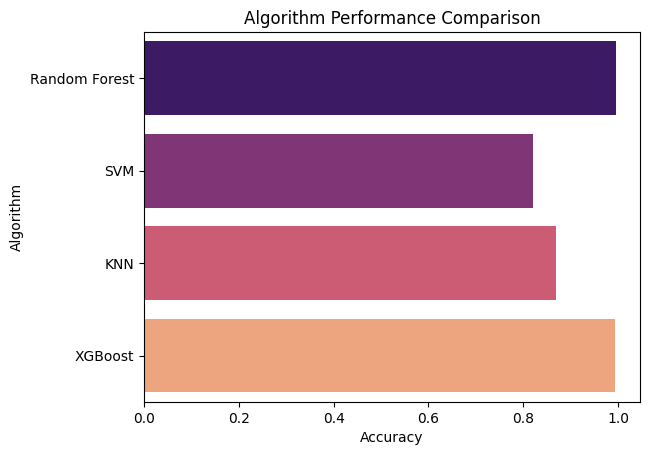

In [37]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Initialize the models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

# Loop through and evaluate
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    results.append({"Algorithm": name, "Accuracy": acc})
    print(f"{name} Accuracy: {acc:.2f}")

# Visualize the Comparison
import pandas as pd
import seaborn as sns
res_df = pd.DataFrame(results)
sns.barplot(x='Accuracy', y='Algorithm', data=res_df, palette='magma')
plt.title('Algorithm Performance Comparison')
plt.show()

In [38]:
y_pred = model.predict(X_test)

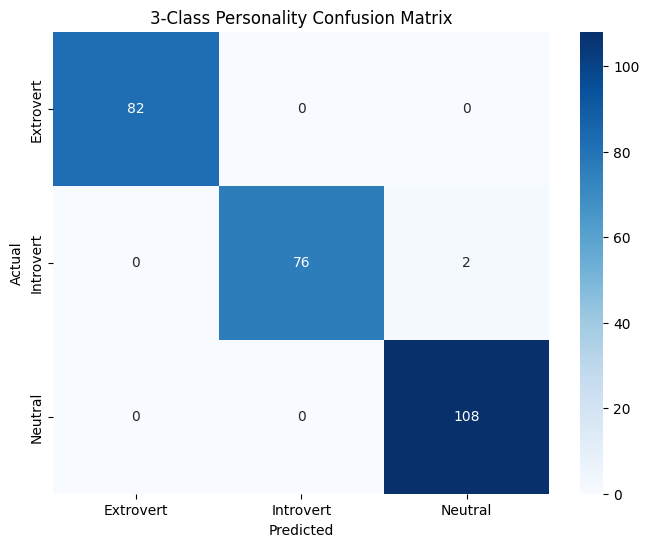

              precision    recall  f1-score   support

   Extrovert       1.00      1.00      1.00        82
   Introvert       1.00      0.97      0.99        78
     Neutral       0.98      1.00      0.99       108

    accuracy                           0.99       268
   macro avg       0.99      0.99      0.99       268
weighted avg       0.99      0.99      0.99       268



In [39]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('3-Class Personality Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test, y_pred, target_names=le.classes_))

/tmp/ipython-input-2542695941.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')


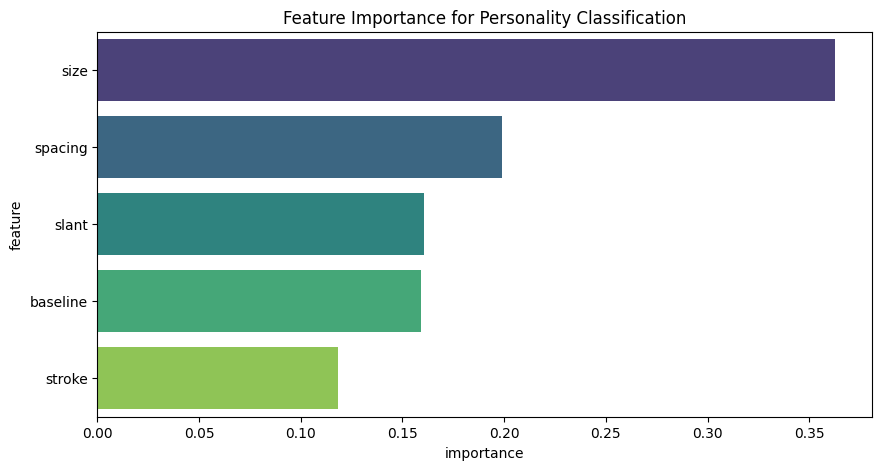

In [40]:
importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
plt.title('Feature Importance for Personality Classification')
plt.show()

In [41]:
X_all = df[['slant', 'baseline', 'spacing', 'stroke','size']]


In [42]:
X_all_scaled = scaler.transform(X_all)


In [43]:
y_pred_encoded = model.predict(X_all_scaled)


In [44]:
y_pred_labels = le.inverse_transform(y_pred_encoded)


In [45]:
df['predicted_personality'] = y_pred_labels


In [46]:
df.to_csv("/content/drive/MyDrive/final_personality_predictions.csv", index=False)

print("✅ Final predictions saved")


✅ Final predictions saved


In [47]:
df['predicted_personality'].value_counts()


,count
predicted_personality,
Neutral,542
Extrovert,412
Introvert,386


In [48]:
pd.crosstab(df['personality'], df['predicted_personality'])


predicted_personality,Extrovert,Introvert,Neutral
personality,,,
Extrovert,412,0,0
Introvert,0,386,2
Neutral,0,0,540


In [49]:
df[df['personality'] != df['predicted_personality']]


,image,slant,baseline,spacing,stroke,size,personality,predicted_personality
418,121_b05-083.png,0.194443,-0.006615,109.0,2.756392,8.0,Introvert,Neutral
585,174_d06-082.png,-0.244447,-0.004569,0.0,2.633994,11.5,Introvert,Neutral


In [50]:
importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

importance_df


,feature,importance
4,size,0.362925
2,spacing,0.198935
0,slant,0.160696
1,baseline,0.158937
3,stroke,0.118506


In [58]:
def explain_3_class_prediction(row):
    explanation = []

    # 1. Slant
    if row['slant'] > slant_thr:
        explanation.append("Right-slant: Emotional expressiveness (Extrovert trait)")
    else:
        explanation.append("Vertical/Left-slant: Emotional restraint (Introvert trait)")

    # 2. Spacing
    if row['spacing'] < spacing_thr:
        explanation.append("Narrow spacing: High sociability (Extrovert trait)")
    else:
        explanation.append("Wide spacing: Need for personal space (Introvert trait)")

    # 3. Stroke/Thickness
    if row['stroke'] > stroke_thr:
        explanation.append("Thick strokes: High energy and confidence (Extrovert trait)")
    else:
        explanation.append("Thin strokes: Cautious and sensitive (Introvert trait)")

    # 4. Size
    if row['size'] > size_thr:
        explanation.append("Large size: Desire for social recognition (Extrovert trait)")
    else:
        explanation.append("Small size: Focus and concentration (Introvert trait)")

    # 5. Baseline
    if row['baseline'] < baseline_thr:
        explanation.append("Rising baseline: Optimism and high energy")
    else:
        explanation.append("Stable/Descending baseline: Emotional control or fatigue")

    return explanation # This returns the LIST for your loop

# --- Apply to Dataframe ---
# We use "; ".join() here so the CSV stores one long sentence instead of a list object
df['decision_basis'] = df.apply(lambda row: "; ".join(explain_3_class_prediction(row)), axis=1)

In [59]:
# Show a sample of each class
display(df.groupby('personality').head(1)[['image', 'personality', 'decision_basis']])

,image,personality,decision_basis
0,236_e04-058.png,Neutral,Right-slant: Emotional expressiveness (Extrove...
4,003_a01-003x.png,Introvert,Vertical/Left-slant: Emotional restraint (Intr...
12,019_a01-122.png,Extrovert,Right-slant: Emotional expressiveness (Extrove...


In [60]:
sample = df.iloc[0]

print(f"--- Analysis for: {sample['image']} ---")
print(f"Personality Category: {sample['personality']}")
print("-" * 40)

# The function now returns a list, so this loop works perfectly:
reasons = explain_3_class_prediction(sample)
for reason in reasons:
    print(f"• {reason}")

--- Analysis for: 236_e04-058.png ---
Personality Category: Neutral
----------------------------------------
• Right-slant: Emotional expressiveness (Extrovert trait)
• Wide spacing: Need for personal space (Introvert trait)
• Thin strokes: Cautious and sensitive (Introvert trait)
• Small size: Focus and concentration (Introvert trait)
• Rising baseline: Optimism and high energy


In [62]:
# Use the new function name: explain_3_class_prediction
df['decision_basis'] = df.apply(
    lambda row: "; ".join(explain_3_class_prediction(row)),
    axis=1
)

# Display the first few rows to verify
print("✅ Explanations generated successfully!")
df[['image', 'personality', 'decision_basis']].head()


✅ Explanations generated successfully!


,image,personality,decision_basis
0,236_e04-058.png,Neutral,Right-slant: Emotional expressiveness (Extrove...
1,655_r02-146.png,Neutral,Right-slant: Emotional expressiveness (Extrove...
2,231_e04-015.png,Neutral,Vertical/Left-slant: Emotional restraint (Intr...
3,231_e04-011.png,Neutral,Vertical/Left-slant: Emotional restraint (Intr...
4,003_a01-003x.png,Introvert,Vertical/Left-slant: Emotional restraint (Intr...


In [63]:
df[['image', 'predicted_personality', 'decision_basis']].to_csv(
    "/content/drive/MyDrive/handwriting_explainable_labels.csv",
    index=False
)

print("✅ Explainable labeled dataset saved")



✅ Explainable labeled dataset saved


/tmp/ipython-input-2504567758.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='personality', data=df, palette='viridis', order=order)


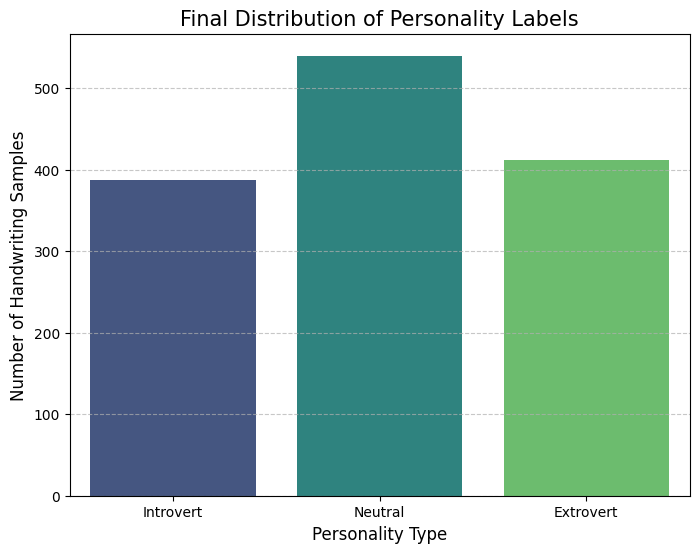

/tmp/ipython-input-2504567758.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')


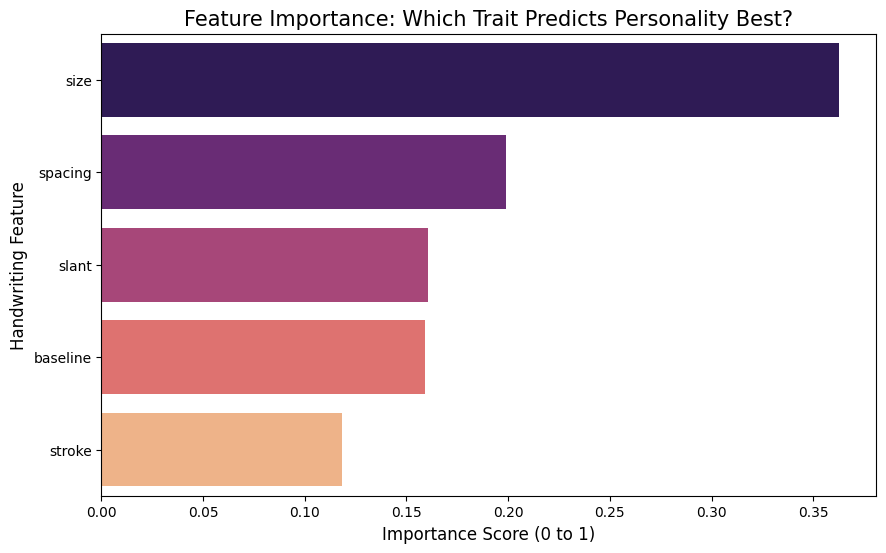

--- Class Percentages ---
personality
Neutral      40.298507
Extrovert    30.746269
Introvert    28.955224
Name: proportion, dtype: float64


In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Distribution of Personality Classes
# This shows how many Introverts, Extroverts, and Neutrals are in your dataset
plt.figure(figsize=(8, 6))
# We define the order so the chart reads like a spectrum
order = ['Introvert', 'Neutral', 'Extrovert']
sns.countplot(x='personality', data=df, palette='viridis', order=order)

plt.title('Final Distribution of Personality Labels', fontsize=15)
plt.xlabel('Personality Type', fontsize=12)
plt.ylabel('Number of Handwriting Samples', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Feature Importance Plot
# This helps you justify your project scientifically by showing which trait (Size, Slant, etc.)
# the Random Forest relied on most.
importances = model.feature_importances_
feature_names = ['slant', 'baseline', 'spacing', 'stroke', 'size']

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('Feature Importance: Which Trait Predicts Personality Best?', fontsize=15)
plt.xlabel('Importance Score (0 to 1)', fontsize=12)
plt.ylabel('Handwriting Feature', fontsize=12)
plt.show()

# 3. Summary Statistics
print("--- Class Percentages ---")
print(df['personality'].value_counts(normalize=True) * 100)

In [65]:
import joblib

# Exporting all the necessary components
joblib.dump(model, 'handwriting_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

# Save thresholds so the app knows the 'average' for Size, Slant, etc.
thresholds = {
    'slant': slant_thr,
    'spacing': spacing_thr,
    'stroke': stroke_thr,
    'size': size_thr,
    'baseline': baseline_thr
}
joblib.dump(thresholds, 'thresholds.pkl')

print("✅ All files exported! Download them from the files folder on the left.")

✅ All files exported! Download them from the files folder on the left.
